# LSTM

## Import libraries

In [291]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [292]:
FROM_DATE = "2022-01-01"
TO_DATE = "2022-05-31"

In [293]:
INPUT_SIZE = 30
OUTPUT_SIZE = 1
NUMBER_OF_TRAIN_WINDOW = 3
NUMBER_OF_VALIDATION_WINDOW = 1
NUMBER_OF_TEST_WINDOW = 1

## Start

### Get data

In [294]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [295]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [296]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [297]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [298]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [299]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [300]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [301]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [302]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [303]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2022-01-01,1494.725000,1505.975000,1489.047500,1505.105000,831770525.0
1,2022-01-02,1499.200000,1512.880000,1492.125000,1511.930000,817006750.0
2,2022-01-03,1503.675000,1519.785000,1495.202500,1518.755000,802242975.0
3,2022-01-04,1508.150000,1526.690000,1498.280000,1525.580000,787479200.0
4,2022-01-05,1529.060000,1535.820000,1522.500000,1522.500000,955697900.0
...,...,...,...,...,...,...
146,2022-04-30,1350.886000,1368.726000,1344.328000,1363.176000,500771680.0
147,2022-05-06,1333.550000,1350.090000,1328.130000,1329.260000,480060200.0
148,2022-05-08,1320.176667,1326.376667,1286.403333,1289.500000,556487333.0
149,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0


In [304]:
data = vn_index_transform_sub_df["close"].copy().tolist()

In [305]:
len(data)

151

In [306]:
train_range = (0, INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW)
validation_window_range = (
    INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW,
    INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + NUMBER_OF_VALIDATION_WINDOW,
)
test_range = (
    INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + NUMBER_OF_VALIDATION_WINDOW,
    INPUT_SIZE
    + NUMBER_OF_TRAIN_WINDOW
    + NUMBER_OF_VALIDATION_WINDOW
    + NUMBER_OF_TEST_WINDOW,
)
print(train_range, validation_window_range, test_range)

(0, 33) (33, 34) (34, 35)


In [307]:
train_set = np.array(data[: INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW]).reshape(-1, 1)
validation_window = np.array(
    data[
        INPUT_SIZE
        + NUMBER_OF_TRAIN_WINDOW : INPUT_SIZE
        + NUMBER_OF_TRAIN_WINDOW
        + NUMBER_OF_VALIDATION_WINDOW
    ]
).reshape(-1, 1)
test_window = np.array(
    data[
        INPUT_SIZE
        + NUMBER_OF_TRAIN_WINDOW
        + NUMBER_OF_VALIDATION_WINDOW : INPUT_SIZE
        + NUMBER_OF_TRAIN_WINDOW
        + NUMBER_OF_VALIDATION_WINDOW
        + NUMBER_OF_TEST_WINDOW
    ]
).reshape(-1, 1)

In [308]:
len(train_set)

33

In [309]:
len(validation_window)

1

In [310]:
len(test_window)

1

In [311]:
# Create scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on train data
train_scaled = scaler.fit_transform(train_set)

validation_scaled = scaler.transform(validation_window)

# Transform test data using same scaler
test_scaled = scaler.transform(test_window)

print("Train scaled shape:", train_scaled.shape)
print("Validation scaled shape:", validation_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (33, 1)
Validation scaled shape: (1, 1)
Test scaled shape: (1, 1)


In [312]:
train_inputs = []
train_outputs = []
for i in range(NUMBER_OF_TRAIN_WINDOW):
    train_input = train_scaled[i : i + INPUT_SIZE]
    train_inputs.append(train_input.squeeze(1))
    train_output = train_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    train_outputs.append(train_output.squeeze(1))
train_inputs = torch.tensor(np.array(train_inputs), dtype=torch.float32)
train_outputs = torch.tensor(np.array(train_outputs), dtype=torch.float32)

In [313]:
train_inputs[:3]

tensor([[0.7382, 0.8143, 0.8905, 0.9666, 0.9323, 1.0000, 0.9990, 0.9069, 0.8148,
         0.7226, 0.5954, 0.7985, 0.6372, 0.6368, 0.0000, 0.0430, 0.2941, 0.3788,
         0.1320, 0.0086, 0.4534, 0.4757, 0.3550, 0.4465, 0.4674, 0.4882, 0.5091,
         0.5300, 0.5508, 0.5717],
        [0.8143, 0.8905, 0.9666, 0.9323, 1.0000, 0.9990, 0.9069, 0.8148, 0.7226,
         0.5954, 0.7985, 0.6372, 0.6368, 0.0000, 0.0430, 0.2941, 0.3788, 0.1320,
         0.0086, 0.4534, 0.4757, 0.3550, 0.4465, 0.4674, 0.4882, 0.5091, 0.5300,
         0.5508, 0.5717, 0.5925],
        [0.8905, 0.9666, 0.9323, 1.0000, 0.9990, 0.9069, 0.8148, 0.7226, 0.5954,
         0.7985, 0.6372, 0.6368, 0.0000, 0.0430, 0.2941, 0.3788, 0.1320, 0.0086,
         0.4534, 0.4757, 0.3550, 0.4465, 0.4674, 0.4882, 0.5091, 0.5300, 0.5508,
         0.5717, 0.5925, 0.6134]])

In [314]:
len(train_inputs[0])

30

In [315]:
train_outputs[:3]

tensor([[0.5925],
        [0.6134],
        [0.6343]])

In [316]:
len(train_outputs[0])

1

In [317]:
validation_inputs = []
validation_outputs = []
for i in range(NUMBER_OF_VALIDATION_WINDOW):
    validation_input = np.concatenate(
        [
            train_scaled[len(train_scaled) - INPUT_SIZE + i + 1 :],
            validation_scaled[: i + OUTPUT_SIZE],
        ],
        axis=0,
    )
    validation_inputs.append(validation_input.squeeze(1))
    validation_output = validation_scaled[i : i + OUTPUT_SIZE]
    validation_outputs.append(validation_output.squeeze(1))
validation_inputs = torch.tensor(np.array(validation_inputs), dtype=torch.float32)
validation_outputs = torch.tensor(np.array(validation_outputs), dtype=torch.float32)

In [318]:
validation_inputs[:3]

tensor([[0.9323, 1.0000, 0.9990, 0.9069, 0.8148, 0.7226, 0.5954, 0.7985, 0.6372,
         0.6368, 0.0000, 0.0430, 0.2941, 0.3788, 0.1320, 0.0086, 0.4534, 0.4757,
         0.3550, 0.4465, 0.4674, 0.4882, 0.5091, 0.5300, 0.5508, 0.5717, 0.5925,
         0.6134, 0.6343, 0.6551]])

In [319]:
len(validation_inputs[0])

30

In [320]:
validation_outputs[:3]

tensor([[0.6551]])

In [321]:
len(validation_outputs[0])

1

In [322]:
test_inputs = []
test_outputs = []
for i in range(NUMBER_OF_TEST_WINDOW):
    test_input = np.concatenate(
        [
            train_scaled[
                len(train_scaled) - INPUT_SIZE + NUMBER_OF_VALIDATION_WINDOW + i + 1 :
            ],
            validation_scaled,
            test_scaled[: i + OUTPUT_SIZE],
        ],
        axis=0,
    )
    test_inputs.append(test_input.squeeze(1))
    test_output = test_scaled[i : i + OUTPUT_SIZE]
    test_outputs.append(test_output.squeeze(1))
test_inputs = torch.tensor(np.array(test_inputs), dtype=torch.float32)
test_outputs = torch.tensor(np.array(test_outputs), dtype=torch.float32)

In [323]:
test_inputs[:3]

tensor([[1.0000, 0.9990, 0.9069, 0.8148, 0.7226, 0.5954, 0.7985, 0.6372, 0.6368,
         0.0000, 0.0430, 0.2941, 0.3788, 0.1320, 0.0086, 0.4534, 0.4757, 0.3550,
         0.4465, 0.4674, 0.4882, 0.5091, 0.5300, 0.5508, 0.5717, 0.5925, 0.6134,
         0.6343, 0.6551, 0.6923]])

In [324]:
len(test_inputs[0])

30

In [325]:
test_outputs[:3]

tensor([[0.6923]])

In [326]:
len(test_outputs[0])

1

In [327]:
train_dataset = TensorDataset(train_inputs, train_outputs)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [328]:
validation_dataset = TensorDataset(validation_inputs, validation_outputs)
validation_dataloader = DataLoader(validation_dataset, batch_size=1)

In [329]:
test_dataset = TensorDataset(test_inputs, test_outputs)
test_dataloader = DataLoader(test_dataset, batch_size=1)

### Create plot

In [330]:
my_visualizer = Visualizer(logger=my_logger)

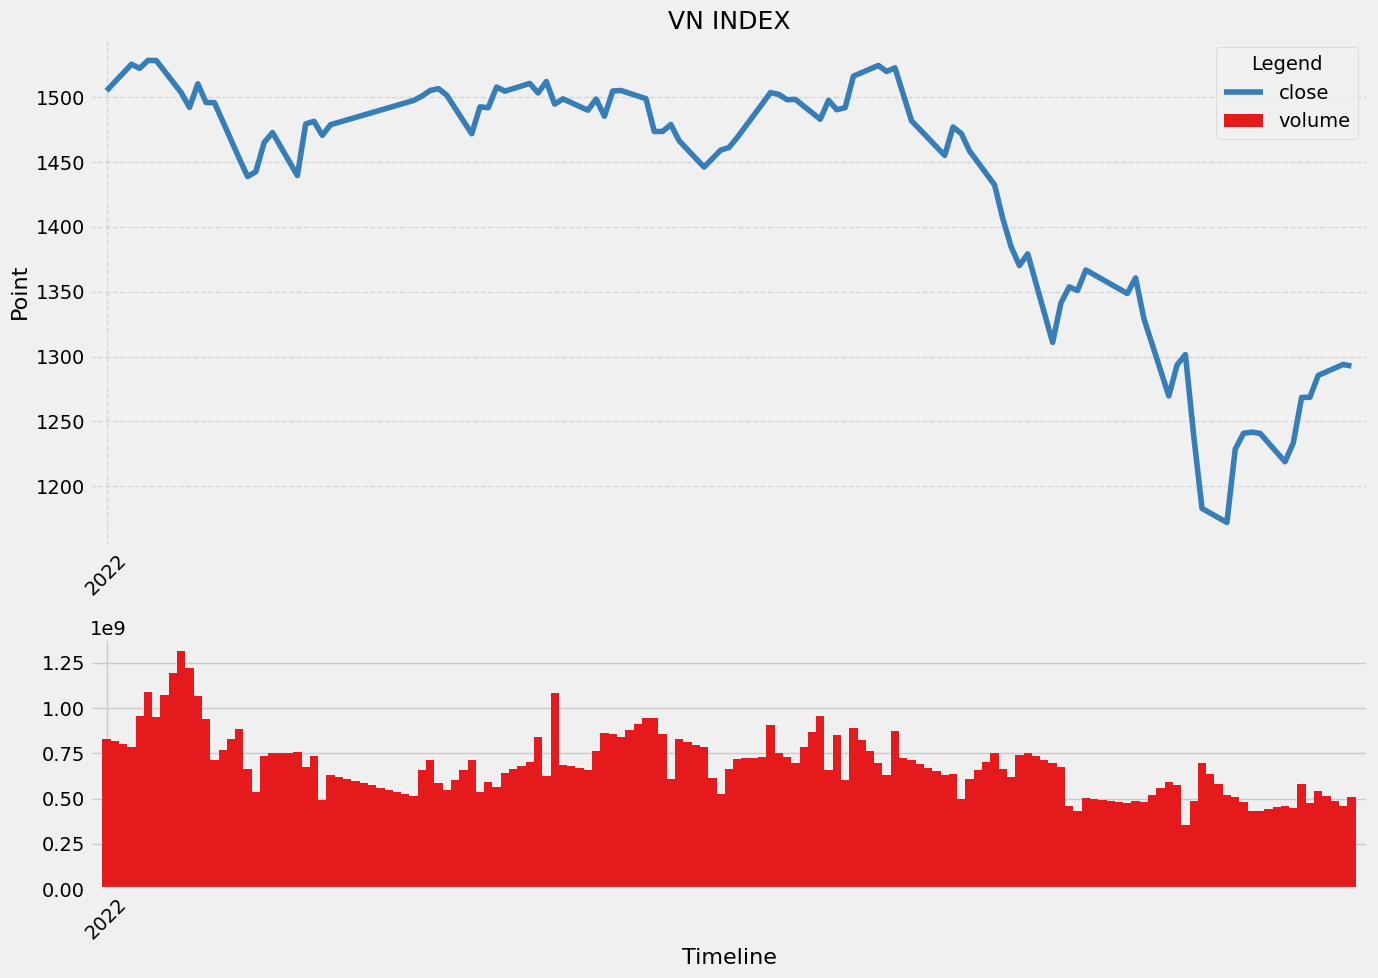

In [331]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create model

In [332]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=1, hidden_size=1, batch_first=True)

    def forward(self, input):

        # input shape: [batch_size, seq_len]

        input = input.unsqueeze(-1)  # → [batch_size, seq_len, 1]

        lstm_out, _ = self.lstm(input)

        prediction = lstm_out[:, -1, :]  # last timestep

        return prediction

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=0.1
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch):  # take a step during validation.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        self.log("val_loss", loss, prog_bar=True)

        return loss

In [333]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-0.0084],
        [-0.0825],
        [-0.2079],
        [ 0.5043]])
lstm.weight_hh_l0 tensor([[0.8440],
        [0.2090],
        [0.1022],
        [0.0882]])
lstm.bias_ih_l0 tensor([-0.6567, -0.5661, -0.9302,  0.8914])
lstm.bias_hh_l0 tensor([ 0.0441, -0.4316,  0.8025,  0.4003])


In [334]:
print("Before training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(0))}")

Before training
Observed: tensor([0.5925])
Predicted: tensor([[-0.0921]], grad_fn=<SliceBackward0>)


### Train model

In [335]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=20,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [336]:
trainer = L.Trainer(
    max_epochs=200, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM │     16 │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 16                                                                                               
Non-trainable params: 0                                                                                            
Total params: 16                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

After optimization, the parameters are...
lstm.weight_ih_l0 tensor([[ 0.4620],
        [-0.7077],
        [ 1.0965],
        [ 0.7590]])
lstm.weight_hh_l0 tensor([[ 1.2280],
        [-0.2679],
        [ 0.2904],
        [ 0.1283]])
lstm.bias_ih_l0 tensor([-0.2138, -1.2136,  0.3759,  1.1160])
lstm.bias_hh_l0 tensor([ 0.4869, -1.0791,  2.1086,  0.6248])


In [337]:
print("After training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(0))}")

After training
Observed: tensor([0.5925])
Predicted: tensor([[0.6141]], grad_fn=<SliceBackward0>)


In [338]:
print("After training")
print(f"Observed: {validation_outputs[0]}")
print(f"Predicted: {model(validation_inputs[0].unsqueeze(0))}")

After training
Observed: tensor([0.6551])
Predicted: tensor([[0.6206]], grad_fn=<SliceBackward0>)


In [339]:
# tensorboard --logdir=src/model/lightning_logs/